# ChainSight — Data Understanding

## Objective

This notebook performs the initial profiling and data-quality assessment of the DataCo Smart Supply Chain dataset.

The analysis focuses on:

- Understanding the dataset structure
- Identifying missing and duplicate records
- Understanding identifiers and relationships
- Profiling numerical and categorical variables
- Investigating delivery-related variables
- Identifying potential target leakage
- Establishing the foundation for data cleaning and feature engineering

## Dataset

The raw dataset contains order-item-level supply-chain records covering customers, products, orders, financial metrics, logistics, delivery performance, and geographic information.

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
DATA_PATH = "../data/raw/DataCoSupplyChainDataset.csv"

print(DATA_PATH)

../data/raw/DataCoSupplyChainDataset.csv


In [3]:
df = pd.read_csv(DATA_PATH, encoding="latin1")

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Dataset loaded successfully.
Rows: 180,519
Columns: 53


In [6]:
print("Number of columns:", len(df.columns))

for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

Number of columns: 53
01. Type
02. Days for shipping (real)
03. Days for shipment (scheduled)
04. Benefit per order
05. Sales per customer
06. Delivery Status
07. Late_delivery_risk
08. Category Id
09. Category Name
10. Customer City
11. Customer Country
12. Customer Email
13. Customer Fname
14. Customer Id
15. Customer Lname
16. Customer Password
17. Customer Segment
18. Customer State
19. Customer Street
20. Customer Zipcode
21. Department Id
22. Department Name
23. Latitude
24. Longitude
25. Market
26. Order City
27. Order Country
28. Order Customer Id
29. order date (DateOrders)
30. Order Id
31. Order Item Cardprod Id
32. Order Item Discount
33. Order Item Discount Rate
34. Order Item Id
35. Order Item Product Price
36. Order Item Profit Ratio
37. Order Item Quantity
38. Sales
39. Order Item Total
40. Order Profit Per Order
41. Order Region
42. Order State
43. Order Status
44. Order Zipcode
45. Product Card Id
46. Product Category Id
47. Product Description
48. Product Image
49. Pr

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

In [7]:
schema = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Non-Null": df.notna().sum().values,
    "Missing": df.isna().sum().values,
    "Unique Values": df.nunique(dropna=True).values
})

schema

,Column,Data Type,Non-Null,Missing,Unique Values
0,Type,str,180519,0,4
1,Days for shipping (real),int64,180519,0,7
2,Days for shipment (scheduled),int64,180519,0,4
3,Benefit per order,float64,180519,0,21998
4,Sales per customer,float64,180519,0,2927
5,Delivery Status,str,180519,0,4
6,Late_delivery_risk,int64,180519,0,2
7,Category Id,int64,180519,0,51
8,Category Name,str,180519,0,50
9,Customer City,str,180519,0,563


## Missing Value Analysis

The first data-quality assessment evaluates the completeness of each variable and identifies fields requiring investigation, transformation, or exclusion.

In [9]:
missing_summary = (
    df.isna()
      .sum()
      .to_frame("Missing Values")
)

missing_summary["Missing %"] = (
    missing_summary["Missing Values"] / len(df) * 100
)

missing_summary = (
    missing_summary[missing_summary["Missing Values"] > 0]
    .sort_values("Missing Values", ascending=False)
)

missing_summary

,Missing Values,Missing %
Product Description,180519,100.000000
Order Zipcode,155679,86.239676
Customer Lname,8,0.004432
Customer Zipcode,3,0.001662


## Duplicate Analysis

Duplicate analysis is performed at the row level. Because the dataset appears to contain order-item records, duplicate rows and duplicate business identifiers are examined separately.

In [10]:
duplicate_rows = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_rows:,}")
print(f"Duplicate percentage: {duplicate_rows / len(df) * 100:.2f}%")

Duplicate rows: 0
Duplicate percentage: 0.00%


In [11]:
print(
    "Customer ID mismatches:",
    (df["Customer Id"] != df["Order Customer Id"]).sum()
)

Customer ID mismatches: 0


In [12]:
print(
    "Product Card ID mismatches:",
    (df["Product Card Id"] != df["Order Item Cardprod Id"]).sum()
)

Product Card ID mismatches: 0


In [13]:
print(df["Late_delivery_risk"].value_counts())
print()
print(df["Late_delivery_risk"].value_counts(normalize=True) * 100)

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Late_delivery_risk
1    54.829132
0    45.170868
Name: proportion, dtype: float64


In [14]:
pd.crosstab(
    df["Late_delivery_risk"],
    df["Delivery Status"],
    normalize="index"
) * 100

Delivery Status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
Late_delivery_risk,,,,
0,51.006843,0.0,9.50921,39.483947
1,0.000000,100.0,0.00000,0.000000


In [15]:
df[[
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Delivery Status",
    "Late_delivery_risk"
]].groupby(
    ["Delivery Status", "Late_delivery_risk"]
).agg(
    count=("Late_delivery_risk", "size"),
    actual_days=("Days for shipping (real)", "mean"),
    scheduled_days=("Days for shipment (scheduled)", "mean")
).reset_index()

,Delivery Status,Late_delivery_risk,count,actual_days,scheduled_days
0,Advance shipping,0,41592,2.498149,4.000000
1,Late delivery,1,98977,4.089253,2.471069
2,Shipping canceled,0,7754,3.476657,2.903921
3,Shipping on time,0,32196,2.975214,2.975214


In [16]:
pd.crosstab(
    df["Days for shipping (real)"],
    df["Late_delivery_risk"]
)

Late_delivery_risk,0,1
Days for shipping (real),,
0,5080,0
1,203,4454
2,30105,26513
3,22006,6759
4,21754,6759
5,1160,27003
6,1234,27489


In [17]:
df["Shipping_Delay_Days"] = (
    df["Days for shipping (real)"]
    - df["Days for shipment (scheduled)"]
)

pd.crosstab(
    df["Shipping_Delay_Days"],
    df["Late_delivery_risk"]
)

Late_delivery_risk,0,1
Shipping_Delay_Days,,
-2,21666,0
-1,21700,0
0,33753,0
1,2690,57957
2,1167,27551
3,280,6772
4,286,6697


In [18]:
pd.crosstab(
    df["Shipping_Delay_Days"] > 0,
    df["Late_delivery_risk"],
    normalize="index"
) * 100

Late_delivery_risk,0,1
Shipping_Delay_Days,,
False,100.000000,0.000000
True,4.277563,95.722437


In [19]:
for i, col in enumerate(df.columns):
    print(f"{i+1:02d}. {col}")

01. Type
02. Days for shipping (real)
03. Days for shipment (scheduled)
04. Benefit per order
05. Sales per customer
06. Delivery Status
07. Late_delivery_risk
08. Category Id
09. Category Name
10. Customer City
11. Customer Country
12. Customer Email
13. Customer Fname
14. Customer Id
15. Customer Lname
16. Customer Password
17. Customer Segment
18. Customer State
19. Customer Street
20. Customer Zipcode
21. Department Id
22. Department Name
23. Latitude
24. Longitude
25. Market
26. Order City
27. Order Country
28. Order Customer Id
29. order date (DateOrders)
30. Order Id
31. Order Item Cardprod Id
32. Order Item Discount
33. Order Item Discount Rate
34. Order Item Id
35. Order Item Product Price
36. Order Item Profit Ratio
37. Order Item Quantity
38. Sales
39. Order Item Total
40. Order Profit Per Order
41. Order Region
42. Order State
43. Order Status
44. Order Zipcode
45. Product Card Id
46. Product Category Id
47. Product Description
48. Product Image
49. Product Name
50. Product

## Column Classification

The dataset contains variables covering order transactions, customers, products, financial performance, logistics, geography, and delivery outcomes.

Each variable is classified according to its business role and its suitability for downstream analytics and predictive modeling.

In [20]:
column_classification = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Unique Values": df.nunique(dropna=True).values,
    "Missing Values": df.isna().sum().values
})

column_classification

,Column,Data Type,Unique Values,Missing Values
0,Type,str,4,0
1,Days for shipping (real),int64,7,0
2,Days for shipment (scheduled),int64,4,0
3,Benefit per order,float64,21998,0
4,Sales per customer,float64,2927,0
5,Delivery Status,str,4,0
6,Late_delivery_risk,int64,2,0
7,Category Id,int64,51,0
8,Category Name,str,50,0
9,Customer City,str,563,0


### Investigation Note

`Shipping_Delay_Days` is a derived variable created temporarily to investigate the relationship between actual and scheduled shipping duration and the `Late_delivery_risk` target.

It is not an original dataset field and will not automatically be included in the final analytical dataset. Its use in predictive modeling will be evaluated separately because it depends on actual shipping performance.

## ChainSight Column Classification

Each variable is classified according to its business purpose and its role in downstream analytics.

The classification distinguishes between:
- Business attributes used for analysis
- Identifiers used for relationships
- Financial and operational measures
- Candidate predictive features
- Target and outcome variables
- Sensitive or unusable fields
- Derived investigation variables

In [21]:
column_roles = {
    "Type": "Order",
    "Days for shipping (real)": "Outcome / Leakage",
    "Days for shipment (scheduled)": "Logistics",
    "Benefit per order": "Financial",
    "Sales per customer": "Financial",
    "Delivery Status": "Outcome / Leakage",
    "Late_delivery_risk": "Target",
    "Category Id": "Product Identifier",
    "Category Name": "Product",
    "Customer City": "Customer / Geography",
    "Customer Country": "Customer / Geography",
    "Customer Email": "Sensitive / Exclude",
    "Customer Fname": "Sensitive / Exclude",
    "Customer Id": "Customer Identifier",
    "Customer Lname": "Sensitive / Exclude",
    "Customer Password": "Sensitive / Exclude",
    "Customer Segment": "Customer",
    "Customer State": "Customer / Geography",
    "Customer Street": "Sensitive / Exclude",
    "Customer Zipcode": "Customer / Geography",
    "Department Id": "Department Identifier",
    "Department Name": "Department",
    "Latitude": "Geography",
    "Longitude": "Geography",
    "Market": "Geography",
    "Order City": "Geography",
    "Order Country": "Geography",
    "Order Customer Id": "Customer Identifier",
    "order date (DateOrders)": "Date",
    "Order Id": "Order Identifier",
    "Order Item Cardprod Id": "Product Identifier",
    "Order Item Discount": "Financial",
    "Order Item Discount Rate": "Financial",
    "Order Item Id": "Order Item Identifier",
    "Order Item Product Price": "Financial / Product",
    "Order Item Profit Ratio": "Financial",
    "Order Item Quantity": "Order / Product",
    "Sales": "Financial",
    "Order Item Total": "Financial",
    "Order Profit Per Order": "Financial",
    "Order Region": "Geography",
    "Order State": "Geography",
    "Order Status": "Order",
    "Order Zipcode": "Geography / Incomplete",
    "Product Card Id": "Product Identifier",
    "Product Category Id": "Product Identifier",
    "Product Description": "Unusable",
    "Product Image": "Product / Reference",
    "Product Name": "Product",
    "Product Price": "Product / Financial",
    "Product Status": "Product",
    "shipping date (DateOrders)": "Outcome / Leakage",
    "Shipping Mode": "Logistics",
    "Shipping_Delay_Days": "Derived / Investigation"
}

column_classification["Business Role"] = (
    column_classification["Column"].map(column_roles)
)

column_classification

,Column,Data Type,Unique Values,Missing Values,Business Role
0,Type,str,4,0,Order
1,Days for shipping (real),int64,7,0,Outcome / Leakage
2,Days for shipment (scheduled),int64,4,0,Logistics
3,Benefit per order,float64,21998,0,Financial
4,Sales per customer,float64,2927,0,Financial
5,Delivery Status,str,4,0,Outcome / Leakage
6,Late_delivery_risk,int64,2,0,Target
7,Category Id,int64,51,0,Product Identifier
8,Category Name,str,50,0,Product
9,Customer City,str,563,0,Customer / Geography


In [22]:
unclassified = column_classification[
    column_classification["Business Role"].isna()
]

print(f"Unclassified columns: {len(unclassified)}")

if len(unclassified) > 0:
    print(unclassified["Column"].tolist())

Unclassified columns: 0


In [23]:
data_dictionary = column_classification[
    [
        "Column",
        "Data Type",
        "Business Role",
        "Unique Values",
        "Missing Values"
    ]
].copy()

data_dictionary

,Column,Data Type,Business Role,Unique Values,Missing Values
0,Type,str,Order,4,0
1,Days for shipping (real),int64,Outcome / Leakage,7,0
2,Days for shipment (scheduled),int64,Logistics,4,0
3,Benefit per order,float64,Financial,21998,0
4,Sales per customer,float64,Financial,2927,0
5,Delivery Status,str,Outcome / Leakage,4,0
6,Late_delivery_risk,int64,Target,2,0
7,Category Id,int64,Product Identifier,51,0
8,Category Name,str,Product,50,0
9,Customer City,str,Customer / Geography,563,0


## Numerical Variable Profiling

Numerical variables are examined using descriptive statistics to understand their ranges, central tendencies, and potential anomalies before data cleaning.

In [24]:
numerical_summary = df.select_dtypes(include=["int64", "float64"]).describe().T

numerical_summary

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.979980,7.000000,31.520000,64.800003,911.799988
Sales per customer,180519.0,183.107609,120.043670,7.490000,104.379997,163.990005,247.399994,1939.989990
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Customer Zipcode,180516.0,35921.126914,37542.461122,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Department Id,180519.0,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933


In [25]:
numerical_summary[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.979980,7.000000,31.520000,64.800003,911.799988
Sales per customer,180519.0,183.107609,120.043670,7.490000,104.379997,163.990005,247.399994,1939.989990
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Customer Zipcode,180516.0,35921.126914,37542.461122,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Department Id,180519.0,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933


## Categorical Variable Profiling

Categorical variables are reviewed to understand their cardinality and identify variables with very low or very high numbers of distinct values.

In [26]:
categorical_summary = pd.DataFrame({
    "Column": df.select_dtypes(include=["str"]).columns,
    "Unique Values": [
        df[col].nunique()
        for col in df.select_dtypes(include=["str"]).columns
    ]
}).sort_values("Unique Values", ascending=False)

categorical_summary

,Column,Unique Values
16,order date (DateOrders),65752
22,shipping date (DateOrders),63701
11,Customer Street,7458
14,Order City,3597
7,Customer Lname,1109
18,Order State,1089
6,Customer Fname,782
3,Customer City,563
15,Order Country,164
20,Product Image,118


In [27]:
for col in ["order date (DateOrders)", "shipping date (DateOrders)"]:
    dates = pd.to_datetime(df[col], errors="coerce")

    print(f"\n{col}")
    print("Minimum:", dates.min())
    print("Maximum:", dates.max())
    print("Invalid dates:", dates.isna().sum())


order date (DateOrders)
Minimum: 2015-01-01 00:00:00
Maximum: 2018-01-31 23:38:00
Invalid dates: 0

shipping date (DateOrders)
Minimum: 2015-01-03 00:00:00
Maximum: 2018-02-06 22:14:00
Invalid dates: 0


## Late Delivery Risk Distribution

The candidate target variable is reviewed to understand its class distribution before predictive modeling.

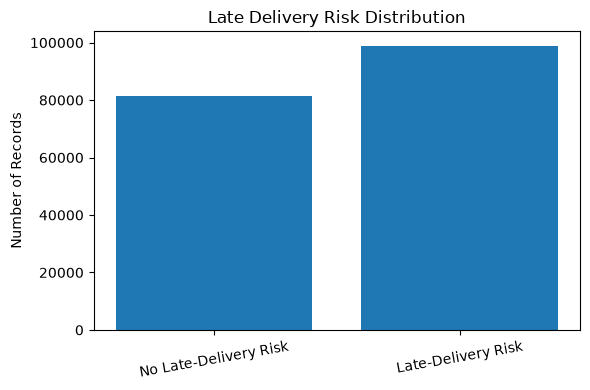

In [28]:
import matplotlib.pyplot as plt

target_counts = df["Late_delivery_risk"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(
    ["No Late-Delivery Risk", "Late-Delivery Risk"],
    target_counts.values
)
plt.title("Late Delivery Risk Distribution")
plt.ylabel("Number of Records")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## Phase 2 Findings

### Dataset Structure

- The dataset contains 180,519 order-item records and 53 original variables.
- Variables cover orders, customers, products, financial performance, logistics, geography, and delivery outcomes.
- The dataset is at an order-item level, with 180,519 unique Order Item Id values and 65,752 unique Order Id values.

### Data Quality

- No exact duplicate rows were identified.
- `Product Description` is completely missing and provides no usable information.
- `Order Zipcode` has 86.24% missing values and requires exclusion or separate investigation.
- `Customer Lname` and `Customer Zipcode` contain only a very small number of missing values.
- `Product Status` has only one unique value and therefore provides no analytical variation.

### Identifier Consistency

- `Customer Id` and `Order Customer Id` are identical across all records.
- `Product Card Id` and `Order Item Cardprod Id` are identical across all records.
- These duplicated identifier fields can be consolidated during data preparation.

### Temporal Coverage

- Order dates range from January 2015 through January 2018.
- Shipping dates range from January 2015 through February 2018.
- No invalid dates were identified.

### Financial Variables

- Profit-related variables contain both positive and negative values.
- Negative profit values will be investigated during exploratory analysis rather than automatically removed.
- Discount and profitability variables will be examined further during EDA.

### Delivery Risk

- `Late_delivery_risk` contains two classes: 0 and 1.
- The classes are relatively balanced, with approximately 45% and 55% of records respectively.
- `Delivery Status` has a direct relationship with `Late_delivery_risk` and therefore represents target leakage for a pre-delivery prediction model.
- `Days for shipping (real)` is an outcome-related variable and will not be used as a predictive feature for the pre-delivery model.
- `shipping date (DateOrders)` will also be excluded from the pre-delivery predictive feature set.

### Predictive Modeling Considerations

The predictive problem will be defined around information that would reasonably be available before the delivery outcome is known.

Outcome-derived variables will therefore be separated from legitimate predictive features during feature engineering.

### Phase 2 Conclusion

The dataset is sufficiently structured for downstream business analytics, SQL analysis, Power BI development, and predictive modeling.

The next phase will focus on creating a clean analytical dataset while preserving the raw source data, converting dates, handling missing values, removing sensitive or unusable fields, consolidating redundant identifiers, and preparing features for subsequent analysis.